# L1 · Notebook 03 — FrozenLake：随机性 MDP

**对应 PPT**：`L1-basic.tex` §转移概率 $P(s'|s,a)$

## 教学目标

1. **打破"动作=确定性"的错觉**：同一动作可能导向多个 $s'$
2. 显式查看转移矩阵 $P(s'|s,a)$
3. 理解为什么需要"期望"$\mathbb{E}_{s'\sim P}$ 出现在 Bellman 方程里

**FrozenLake-v1**：4×4 冰面网格，agent 试图从 S 走到 G，但冰面**很滑**——选定一个方向后，只有 1/3 概率真正按此方向走，剩下 2/3 平均分给两个垂直方向。

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))

import numpy as np
import gymnasium as gym
import matplotlib.pyplot as plt
from shared.plotting import setup_chinese_font

setup_chinese_font()

env = gym.make('FrozenLake-v1', is_slippery=True, map_name='4x4')
print('observation_space:', env.observation_space)  # Discrete(16)
print('action_space:    ', env.action_space)        # Discrete(4): L,D,R,U
ACTION_NAMES = ['LEFT', 'DOWN', 'RIGHT', 'UP']
print('actions: 0=LEFT, 1=DOWN, 2=RIGHT, 3=UP')

observation_space: Discrete(16)
action_space:     Discrete(4)
actions: 0=LEFT, 1=DOWN, 2=RIGHT, 3=UP


## 1. 看地图

```
S F F F
F H F H
F F F H
H F F G
```
S=start (s=0), F=frozen, H=hole (掉入即终止 r=0), G=goal (r=+1)

In [2]:
desc = env.unwrapped.desc.astype(str)
print('地图:')
for row in desc:
    print('  ' + ' '.join(row))

地图:
  S F F F
  F H F H
  F F F H
  H F F G


## 2. 直接看转移概率 $P(s'|s,a)$

Gymnasium 的 `env.unwrapped.P` 是字典 `{state: {action: [(prob, next_state, reward, done), ...]}}`。

In [3]:
P = env.unwrapped.P

# 看 s=0（起点）取 RIGHT 的转移分布
s, a = 0, 2
print(f'从 s={s} 取 a={ACTION_NAMES[a]} 的转移分布:')
print(f"{'prob':<8} {'s_next':<8} {'reward':<8} {'done'}")
print('-' * 36)
for prob, s_next, r, done in P[s][a]:
    print(f'{prob:<8.4f} {s_next:<8} {r:<8} {done}')

从 s=0 取 a=RIGHT 的转移分布:
prob     s_next   reward   done
------------------------------------
0.3333   4        0.0      False
0.3333   1        0.0      False
0.3333   0        0.0      False


**关键观察**：
- 输入动作 RIGHT，但实际只有 1/3 概率向右走到 s=1
- 1/3 概率"打滑"向上变成 stay
- 1/3 概率"打滑"向下走到 s=4

→ 这就是为什么 Bellman 方程里有 $\mathbb{E}_{s'\sim P(\cdot|s,a)}$。

## 3. 实证：同一动作 8 次，看 4 个不同 s'

In [4]:
from collections import Counter

obs, _ = env.reset(seed=0)
outcomes = []
for trial in range(60):
    env.reset(seed=trial)
    obs, r, term, trunc, _ = env.step(2)  # RIGHT
    outcomes.append(int(obs))

counts = Counter(outcomes)
print(f'从 s=0 取 RIGHT 60 次的实证频率:')
for s_next, n in sorted(counts.items()):
    print(f'  s_next={s_next}: count={n}, freq={n/60:.4f} (理论 0.3333)')

从 s=0 取 RIGHT 60 次的实证频率:
  s_next=0: count=19, freq=0.3167 (理论 0.3333)
  s_next=1: count=24, freq=0.4000 (理论 0.3333)
  s_next=4: count=17, freq=0.2833 (理论 0.3333)


## 4. 把 $P(s'|s,a)$ 转成 16×4×16 张量

In [5]:
nS, nA = 16, 4
P_tensor = np.zeros((nS, nA, nS))
R_tensor = np.zeros((nS, nA))
for s in range(nS):
    for a in range(nA):
        for prob, s_next, r, done in P[s][a]:
            P_tensor[s, a, s_next] += prob
            R_tensor[s, a] += prob * r

print('P_tensor shape:', P_tensor.shape, ' R_tensor shape:', R_tensor.shape)
print('每个 (s,a) 的转移概率和 (应全为 1):')
print(P_tensor.sum(axis=2).round(6))

P_tensor shape: (16, 4, 16)  R_tensor shape: (16, 4)
每个 (s,a) 的转移概率和 (应全为 1):
[[1. 1. 1. 1.]
 [1. 1. 1. 1.]
 [1. 1. 1. 1.]
 [1. 1. 1. 1.]
 [1. 1. 1. 1.]
 [1. 1. 1. 1.]
 [1. 1. 1. 1.]
 [1. 1. 1. 1.]
 [1. 1. 1. 1.]
 [1. 1. 1. 1.]
 [1. 1. 1. 1.]
 [1. 1. 1. 1.]
 [1. 1. 1. 1.]
 [1. 1. 1. 1.]
 [1. 1. 1. 1.]
 [1. 1. 1. 1.]]


## 5. 可视化：从 s=0 出发，每个动作的 $P(s'|s,a)$ 热图

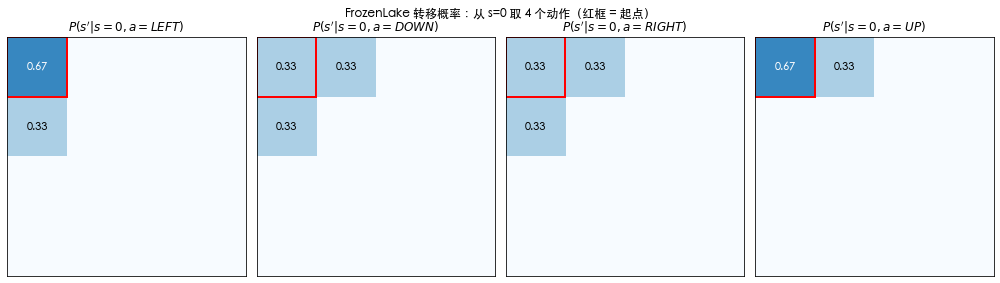

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for a, ax in enumerate(axes):
    p = P_tensor[0, a].reshape(4, 4)
    im = ax.imshow(p, cmap='Blues', vmin=0, vmax=1)
    for r in range(4):
        for c in range(4):
            if p[r, c] > 0:
                ax.text(c, r, f'{p[r, c]:.2f}', ha='center', va='center',
                        color='white' if p[r, c] > 0.5 else 'black', fontsize=11)
    # mark start s=0
    ax.add_patch(plt.Rectangle((-0.5, -0.5), 1, 1, fill=False, edgecolor='red', linewidth=2))
    ax.set_title(f'$P(s\'|s=0, a={ACTION_NAMES[a]})$')
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle('FrozenLake 转移概率：从 s=0 取 4 个动作（红框 = 起点）')
plt.tight_layout()
plt.savefig('figures/frozenlake_P.png', dpi=120, bbox_inches='tight')
plt.show()

## 6. 随机策略基线：成功率

In [7]:
env = gym.make('FrozenLake-v1', is_slippery=True)
n_eps, n_success = 1000, 0
rng = np.random.default_rng(0)
for ep in range(n_eps):
    env.reset(seed=int(rng.integers(0, 1_000_000)))
    done = False
    while not done:
        a = int(rng.integers(0, 4))
        obs, r, term, trunc, _ = env.step(a)
        done = term or trunc
    if r > 0:
        n_success += 1
env.close()
print(f'随机策略 {n_eps} 局成功率: {n_success/n_eps:.3f}  ({n_success}/{n_eps})')
print('(L4 价值迭代后通常可达 ~0.74)')

随机策略 1000 局成功率: 0.012  (12/1000)
(L4 价值迭代后通常可达 ~0.74)


## 7. 课堂诊断小结

| 论断 | 数值 |
|---|---|
| 同一动作 → 多个 $s'$ | RIGHT 实证有 4 个 outcome |
| 转移分布之和 = 1 | `P.sum(axis=2)` 全为 1 |
| 随机策略成功率 | ~5% |
| → 需要规划 / 学习 | L4 解 Bellman 后 ~74% |

## 思考题

1. 如果 `is_slippery=False`（确定性 FrozenLake），随机策略成功率会显著提高吗？
2. Bellman 方程 $v(s)=\sum_a \pi(a|s) [r(s,a) + \gamma \sum_{s'} P(s'|s,a) v(s')]$ 中，哪一项体现了**策略的随机性**，哪一项体现了**环境的随机性**？
3. 把 16×4×16 的 P 张量交给 L4 价值迭代，能直接用矩阵化代码：$V_{k+1}(s) = \max_a [R(s,a) + \gamma \sum_{s'} P(s'|s,a) V_k(s')]$。试想这种向量化对大状态空间有什么好处。